# 05 · 過擬合與正則化

神經網路參數多、能力強，所以特別容易**過擬合**——把訓練資料背得滾瓜爛熟，對沒看過的資料卻很差。這堂課先製造過擬合給你看，再用 **dropout** 和 **weight decay** 把它壓下去。

## 學習目標

- 用「訓練 vs 測試」準確率曲線看見過擬合
- 用 **dropout** 隨機關閉神經元，逼網路別死背
- 用 **weight decay**（L2）懲罰過大的權重
- 知道 **data augmentation** 的概念

## 1. 故意製造過擬合

只用 **500 筆** MNIST 訓練、跑很多輪，網路會輕鬆背完訓練集。我們逐輪記錄訓練與測試準確率。

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

torch.manual_seed(0)
tfm = transforms.ToTensor()
train_full = datasets.MNIST("data", train=True, download=True, transform=tfm)
test_full = datasets.MNIST("data", train=False, download=True, transform=tfm)
train = Subset(train_full, range(500))          # 故意只用很少資料
test = Subset(test_full, range(2000))
train_loader = DataLoader(train, batch_size=64, shuffle=True)
test_loader = DataLoader(test, batch_size=512)

def acc(model, loader):
    model.eval(); c = 0; n = 0
    with torch.no_grad():
        for xb, yb in loader:
            c += (model(xb).argmax(1) == yb).sum().item(); n += len(yb)
    return c / n

def train_track(model, epochs=40, weight_decay=0.0):
    opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=weight_decay)
    crit = nn.CrossEntropyLoss()
    tr, te = [], []
    for _ in range(epochs):
        model.train()
        for xb, yb in train_loader:
            opt.zero_grad(); crit(model(xb), yb).backward(); opt.step()
        tr.append(acc(model, train_loader)); te.append(acc(model, test_loader))
    return tr, te

def make_mlp(dropout=0.0):
    return nn.Sequential(
        nn.Flatten(),
        nn.Linear(28 * 28, 256), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 256), nn.ReLU(), nn.Dropout(dropout),
        nn.Linear(256, 10),
    )

torch.manual_seed(0)
tr_plain, te_plain = train_track(make_mlp(dropout=0.0))
print(f"無正則化 → 訓練 {tr_plain[-1]:.1%}　測試 {te_plain[-1]:.1%}")

無正則化 → 訓練 100.0%　測試 81.5%


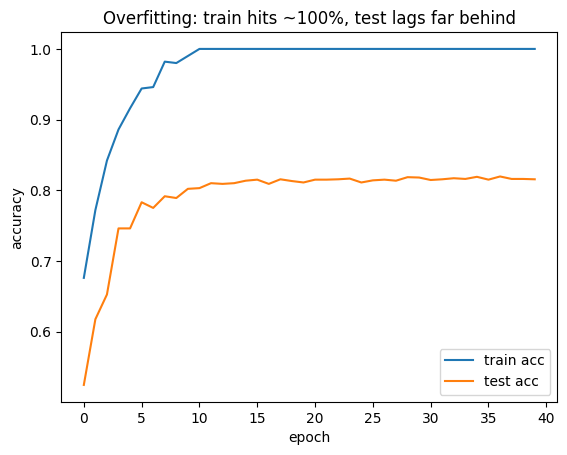

In [2]:
plt.plot(tr_plain, label="train acc")
plt.plot(te_plain, label="test acc")
plt.xlabel("epoch"); plt.ylabel("accuracy"); plt.legend()
plt.title("Overfitting: train hits ~100%, test lags far behind")
plt.show()

訓練準確率衝到 ~100%，測試卻卡在低點——兩條線之間的鴻溝就是過擬合。

## 2. 加上 dropout + weight decay

- **Dropout**：訓練時隨機把一部分神經元歸零，逼網路不能依賴特定幾個神經元、學更穩健的特徵。
- **Weight decay**：在 loss 裡加一項懲罰大權重（L2），讓模型更平滑。

有正則化 → 訓練 100.0%　測試 82.7%


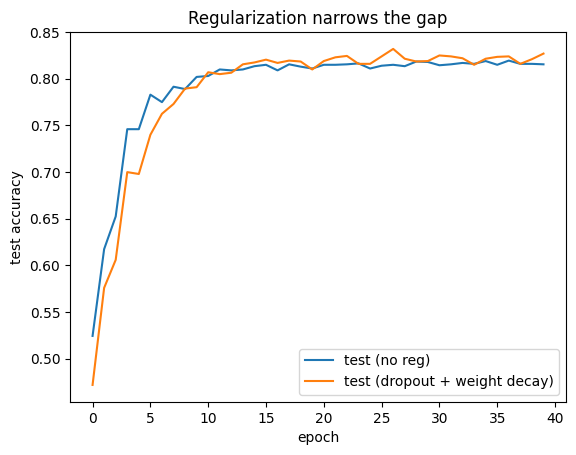

In [3]:
torch.manual_seed(0)
tr_reg, te_reg = train_track(make_mlp(dropout=0.4), weight_decay=1e-3)
print(f"有正則化 → 訓練 {tr_reg[-1]:.1%}　測試 {te_reg[-1]:.1%}")

plt.plot(te_plain, label="test (no reg)")
plt.plot(te_reg, label="test (dropout + weight decay)")
plt.xlabel("epoch"); plt.ylabel("test accuracy"); plt.legend()
plt.title("Regularization narrows the gap")
plt.show()

正則化後，訓練準確率不再貼到 100%，但**測試準確率提升**——犧牲一點背書能力，換來更好的泛化。

> **Data augmentation** 是另一招：對訓練影像隨機平移、旋轉、翻轉，等於免費變出更多樣本，是視覺任務對抗過擬合的標配（`torchvision.transforms` 內建）。

## 小結

- 神經網路容易過擬合：訓練分數高、測試分數差。
- **Dropout** 隨機關神經元、**weight decay** 懲罰大權重，都能改善泛化。
- **Data augmentation** 靠隨機變換訓練資料來擴增樣本。

## 練習

1. 把 dropout 調到 0.7，測試準確率還會更好嗎？還是反而變差（正則化過頭）？
2. 把訓練資料從 500 加到 5000，過擬合的鴻溝會縮小嗎？

下一課，學會把訓練搬到 **GPU** 上加速。